# Customer Analytics with RFM & CLV Modeling

This project builds an end-to-end customer analytics pipeline using the Olist e-commerce dataset.

The main objective is to understand customer purchasing behavior and estimate future customer value.

Tech stack used in this project:

- Python
- SQL (MySQL)
- Pandas / NumPy
- Lifetimes (BG/NBD & Gamma-Gamma models)
- Power BI for visualization

Pipeline:

SQL → Analytical Base  
Python → RFM & CLV Modeling  
Output → SQL tables → Power BI dashboard

In [2]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

## Data Loading

The dataset is retrieved from a MySQL analytical view that contains cleaned and enriched order-level data.

The data comes from the **Olist Brazilian E-commerce dataset**, which includes information about:

- customers
- orders
- order payments
- product categories
- delivery performance
- customer reviews

This analytical base is used to build customer-level metrics required for RFM and CLV modeling.

In [4]:
## SQL Connection
conn = pymysql.connect(database = "olist", user = "root", password = "160510", local_infile=True)
cursor = conn.cursor()

In [5]:
df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)
df_all.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_23760\383586695.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


## Data Preparation

In this stage, raw transactional data is transformed into a customer-level dataset.

Key steps:

- Converting timestamps to datetime format
- Aggregating orders at the customer level
- Calculating revenue metrics
- Handling missing values
- Creating behavioral features

These transformations prepare the dataset for customer segmentation and lifetime value modeling.

In [10]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96478 non-null  object        
 6   carrier_ts                96478 non-null  object        
 7   delivered_ts              96478 non-null  object        
 8   est_delivery_ts           96478 non-null  datetime64[ns]
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight     

In [12]:
# Editing the data type of the date columns:
date_cols = ["purchase_ts","approved_ts","carrier_ts","delivered_ts","review_creation_date"]
for c in date_cols:
    if c in df_all.columns:
        df_all[c] = pd.to_datetime(df_all[c], errors="coerce")

In [14]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96464 non-null  datetime64[ns]
 6   carrier_ts                96476 non-null  datetime64[ns]
 7   delivered_ts              96470 non-null  datetime64[ns]
 8   est_delivery_ts           96478 non-null  datetime64[ns]
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight     

In [16]:
cat_cols = ["main_category_by_item","main_category_by_revenue","order_type","all_categories"]
for c in cat_cols:
    if c in df_all.columns:
        df_all[c] = df_all[c].astype(str).str.replace(r"[\r\n\t]", "", regex=True).str.strip()

In [18]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP


## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is used to segment customers based on their purchasing behavior.

Metrics:

- **Recency** → Days since last purchase
- **Frequency** → Number of transactions
- **Monetary** → Total spending

These metrics help identify valuable customers and detect churn risk.

In [21]:
## RFM

analysis_date = df_all["purchase_ts"].max() + pd.Timedelta(days=1)

rfm = (df_all.groupby("customer_unique_id", as_index=False).agg(
    recency_days = ("purchase_ts", lambda x: (analysis_date - x.max()).days),
    frequency = ("order_id", "nunique"),
    monetary=("total_payment","sum"),
    last_purchase=("purchase_ts","max"))
)

rfm["aov"] = rfm["monetary"] / rfm["frequency"]

rfm.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000


In [23]:
rfm.describe().T

,count,mean,min,25%,50%,75%,max,std
recency_days,93358.00000,237.94177,1.00000,114.00000,219.00000,346.00000,714.00000,152.59145
frequency,93358.00000,1.03342,1.00000,1.00000,1.00000,1.00000,15.00000,0.20910
monetary,93358.00000,162.48219,0.00000,61.32000,106.10000,180.04000,13664.08000,223.92195
last_purchase,93358,2018-01-04 03:47:36.045363200,2016-09-15 12:16:38,2017-09-17 18:25:15,2018-01-23 00:12:12.500000,2018-05-07 17:22:34.750000128,2018-08-29 15:00:37,NaN
aov,93358.00000,157.68395,0.00000,60.49250,103.55000,174.81000,13664.08000,217.17680


In [25]:
# We need to remove the observation where Monetary is 0.
rfm = rfm[rfm["monetary"] > 0]

rfm.describe().T

,count,mean,min,25%,50%,75%,max,std
recency_days,93357.00000,237.93667,1.00000,114.00000,219.00000,346.00000,695.00000,152.58432
frequency,93357.00000,1.03342,1.00000,1.00000,1.00000,1.00000,15.00000,0.20910
monetary,93357.00000,162.48393,0.01000,61.32000,106.10000,180.04000,13664.08000,223.92252
last_purchase,93357,2018-01-04 03:54:56.246505472,2016-10-03 16:56:50,2017-09-17 18:27:12,2018-01-23 00:18:46,2018-05-07 17:23:11,2018-08-29 15:00:37,NaN
aov,93357.00000,157.68564,0.01000,60.50000,103.55000,174.81000,13664.08000,217.17735


In [27]:
# Number of customers
rfm.shape[0]

93357

### Calculating RFM Scores

Customers are scored using quintiles:

Recency score → lower recency = higher score  
Frequency score → higher frequency = higher score  
Monetary score → higher spending = higher score

The RFM score is created by combining recency and frequency scores.

In [30]:
rfm["recency_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1])
rfm["frequency_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["monetary_score"] = pd.qcut(rfm["monetary"], 5, labels = [1, 2, 3, 4, 5])

In [32]:
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4


In [34]:
rfm["RFM_SCORE"] = (rfm["recency_score"].astype(str) +
                    rfm["frequency_score"].astype(str))

In [36]:
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21


### Creating Customer Segments

Customers are assigned to behavioral segments using RFM scores.

The segmentation logic is inspired by commonly used CRM segmentation frameworks.

Segments include:

- Champions
- Loyal Customers
- Potential Loyalists
- Promising
- Need Attention
- At Risk
- Hibernating

In [39]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm["segment"] = rfm["RFM_SCORE"].replace(seg_map, regex=True)

rfm.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating


## Segment Analysis

After segmentation, we analyze:

- Number of customers in each segment
- Revenue contribution
- Average customer value

This helps identify high-value customer groups and churn risks.

In [42]:
rfm[["segment", "recency_days", "frequency", "monetary"]].groupby("segment").agg(["mean","count"])

recency_days        frequency         monetary       
                            mean  count      mean  count      mean  count
segment                                                                  
about_to_sleep         220.24156   7373   1.00000   7373 151.87982   7373
at_Risk                394.79397  14935   1.00000  14935 157.24465  14935
cant_loose             394.34864   7294   1.14628   7294 176.90593   7294
champions               45.53298   7535   1.09595   7535 173.60504   7535
hibernating            395.50814  14986   1.00000  14986 160.19309  14986
loyal_customers        178.56668  15005   1.08864  15005 167.46139  15005
need_attention         219.99068   3757   1.00000   3757 145.90256   3757
new_customers           45.94946   3720   1.00000   3720 158.50351   3720
potential_loyalists     90.61082  14993   1.00000  14993 162.31887  14993
promising              135.95424   3759   1.00000   3759 164.25652   3759

In [44]:
rfm[rfm["segment"] == "need_attention"].head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
38484,694d80d9924784daa43b1482ccda0af6,252,1,864.72000,2017-12-20 15:36:44,864.72000,3,3,5,33,need_attention
38492,69574480ad966b4126095fefd1b28112,237,1,271.23000,2018-01-04 22:09:33,271.23000,3,3,5,33,need_attention
38501,695bbb3da4afc645d1f16657ae1bfc9f,198,1,153.41000,2018-02-13 10:15:52,153.41000,3,3,4,33,need_attention
38514,69625f87b8828043516f9ccc62f8e7ef,198,1,126.43000,2018-02-12 22:10:33,126.43000,3,3,3,33,need_attention
38515,6962878a47e9d4139c78394fb4c2adc6,238,1,434.95000,2018-01-04 10:27:42,434.95000,3,3,5,33,need_attention


In [46]:
rfm.to_csv("rfm.csv", index=False)

### Creating a Reusable RFM Function

In [49]:
def create_rfm(dataframe, csv=False):
    
    # DATA PREPARATION
    date_cols = ["purchase_ts","approved_ts","carrier_ts","delivered_ts","review_creation_date"]
    for c in date_cols:
        if c in dataframe.columns:
            dataframe[c] = pd.to_datetime(dataframe[c], errors="coerce")

    cat_cols = ["main_category_by_item","main_category_by_revenue","order_type","all_categories"]
    for c in cat_cols:
        if c in dataframe.columns:
            dataframe[c] = dataframe[c].astype(str).str.replace(r"[\r\n\t]", "", regex=True).str.strip()

    # Calculating RFM Metrics
    analysis_date = dataframe["purchase_ts"].max() + pd.Timedelta(days=1)

    rfm = (dataframe.groupby("customer_unique_id", as_index=False).agg(
        recency_days = ("purchase_ts", lambda x: (analysis_date - x.max()).days),
        frequency = ("order_id", "nunique"),
        monetary=("total_payment","sum"),
        last_purchase=("purchase_ts","max"))
          )

    rfm["aov"] = rfm["monetary"] / rfm["frequency"]
    rfm = rfm[rfm["monetary"] > 0]

    # Calculating RFM Scores
    rfm["recency_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1])
    rfm["frequency_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
    rfm["monetary_score"] = pd.qcut(rfm["monetary"], 5, labels = [1, 2, 3, 4, 5])

    rfm["RFM_SCORE"] = (rfm["recency_score"].astype(str) +
                        rfm["frequency_score"].astype(str))

    # SEGMENT NAMING
    seg_map = {
        r'[1-2][1-2]': 'hibernating',
        r'[1-2][3-4]': 'at_Risk',
        r'[1-2]5': 'cant_loose',
        r'3[1-2]': 'about_to_sleep',
        r'33': 'need_attention',
        r'[3-4][4-5]': 'loyal_customers',
        r'41': 'promising',
        r'51': 'new_customers',
        r'[4-5][2-3]': 'potential_loyalists',
        r'5[4-5]': 'champions'
    }

    rfm["segment"] = rfm["RFM_SCORE"].replace(seg_map, regex=True)
    rfm.index = rfm.index.astype(int)

    if csv:
        rfm.to_csv("rfm.csv", index=False)

    return rfm

In [51]:
df_copy = df_all.copy()

In [53]:
rfm_new = create_rfm(df_copy, csv=True)

In [54]:
rfm_new.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating


In [55]:
rfm_new.isnull().sum()

customer_unique_id    0
recency_days          0
frequency             0
monetary              0
last_purchase         0
aov                   0
recency_score         0
frequency_score       0
monetary_score        0
RFM_SCORE             0
segment               0
dtype: int64

In [56]:
rfm_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93357 entries, 0 to 93357
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93357 non-null  object        
 1   recency_days        93357 non-null  int64         
 2   frequency           93357 non-null  int64         
 3   monetary            93357 non-null  float64       
 4   last_purchase       93357 non-null  datetime64[ns]
 5   aov                 93357 non-null  float64       
 6   recency_score       93357 non-null  category      
 7   frequency_score     93357 non-null  category      
 8   monetary_score      93357 non-null  category      
 9   RFM_SCORE           93357 non-null  object        
 10  segment             93357 non-null  object        
dtypes: category(3), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 6.3+ MB


In [61]:
# Type conversion

for col in ["recency_score", "frequency_score", "monetary_score"]:
    if col in rfm_new.columns:
        rfm_new[col] = pd.to_numeric(rfm_new[col], errors="coerce")

In [63]:
rfm_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93357 entries, 0 to 93357
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93357 non-null  object        
 1   recency_days        93357 non-null  int64         
 2   frequency           93357 non-null  int64         
 3   monetary            93357 non-null  float64       
 4   last_purchase       93357 non-null  datetime64[ns]
 5   aov                 93357 non-null  float64       
 6   recency_score       93357 non-null  int64         
 7   frequency_score     93357 non-null  int64         
 8   monetary_score      93357 non-null  int64         
 9   RFM_SCORE           93357 non-null  object        
 10  segment             93357 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(3)
memory usage: 8.2+ MB


Segment distribution (number of customers)

## RFM Visualization

Several visualizations are created to understand customer behavior:

- Segment distribution
- Segment revenue contribution
- RFM heatmap
- Recency distribution

These charts help interpret customer purchasing patterns.

These visualizations help identify:

- valuable customer groups
- churn risk segments
- purchasing patterns across customer cohorts

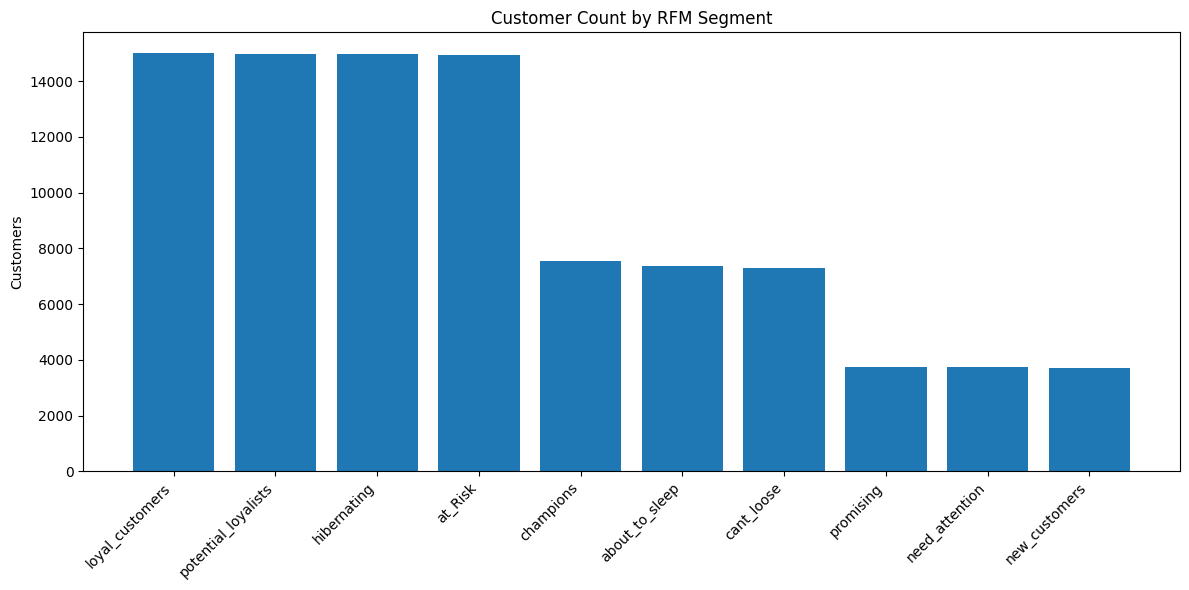

In [67]:
seg_counts = rfm_new["segment"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(seg_counts.index, seg_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Customer Count by RFM Segment")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

Segment-based revenue and customer numbers

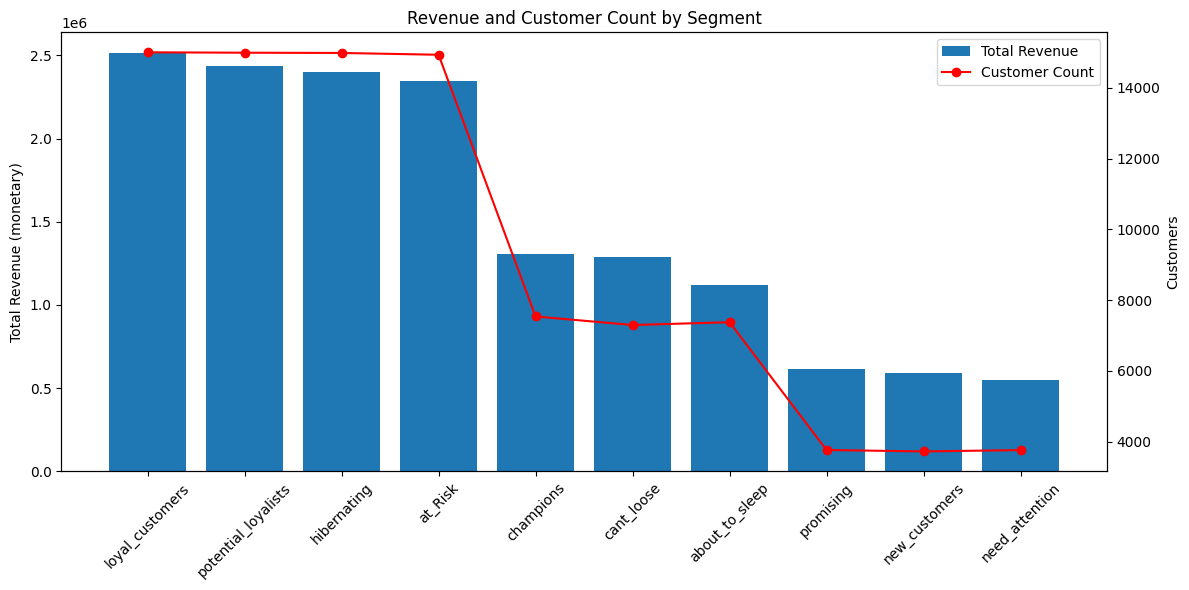

In [70]:
seg_summary = (rfm_new.groupby("segment", as_index=False)
              .agg(customers=("customer_unique_id", "nunique"),
                  revenue=("monetary", "sum"))
              .sort_values("revenue", ascending=False))

fig, ax1 = plt.subplots(figsize=(12,6))

bar = ax1.bar(seg_summary["segment"], seg_summary["revenue"], label="Total Revenue")
ax1.set_ylabel("Total Revenue (monetary)")
ax1.set_title("Revenue and Customer Count by Segment")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
line = ax2.plot(seg_summary["segment"], seg_summary["customers"], marker="o", color="r", label="Customer Count")
ax2.set_ylabel("Customers")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()

RFM Heatmap

In [73]:
rfm_new.pivot_table(index="recency_score", columns="frequency_score",
                   values="customer_unique_id", aggfunc="nunique", fill_value=0) \
.sort_index(ascending=True)

frequency_score,1,2,3,4,5
recency_score,,,,,
1,3827,3732,3703,3737,3639
2,3656,3771,3723,3772,3655
3,3710,3663,3757,3826,3753
4,3759,3778,3742,3602,3824
5,3720,3727,3746,3734,3801


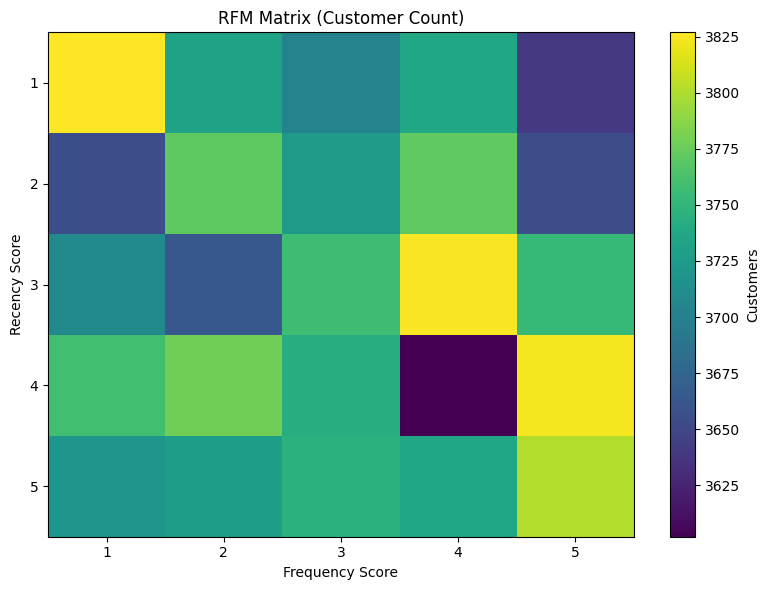

In [75]:
rfm_pivot = (rfm_new.pivot_table(index="recency_score", columns="frequency_score",
                   values="customer_unique_id", aggfunc="nunique", fill_value=0) \
             .sort_index(ascending=True))

plt.figure(figsize=(8,6))
plt.imshow(rfm_pivot.values, aspect="auto")
plt.colorbar(label="Customers")
plt.xticks(range(rfm_pivot.shape[1]), rfm_pivot.columns)
plt.yticks(range(rfm_pivot.shape[0]), rfm_pivot.index)
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")
plt.title("RFM Matrix (Customer Count)")
plt.tight_layout()
plt.show()

Recency distribution

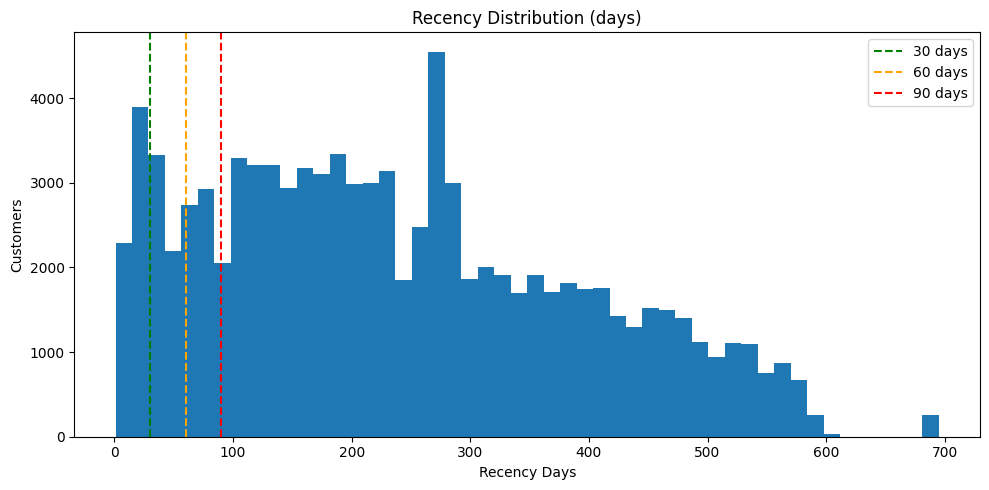

In [78]:
plt.figure(figsize=(10,5))
plt.hist(rfm_new["recency_days"].values, bins=50)
plt.axvline(30, linestyle = "--", color="green", label="30 days")
plt.axvline(60, linestyle = "--", color="orange", label="60 days")
plt.axvline(90, linestyle = "--", color="red", label="90 days")
plt.title("Recency Distribution (days)")
plt.xlabel("Recency Days")
plt.ylabel("Customers")
plt.tight_layout()
plt.legend()
plt.show()

Monetary distribution

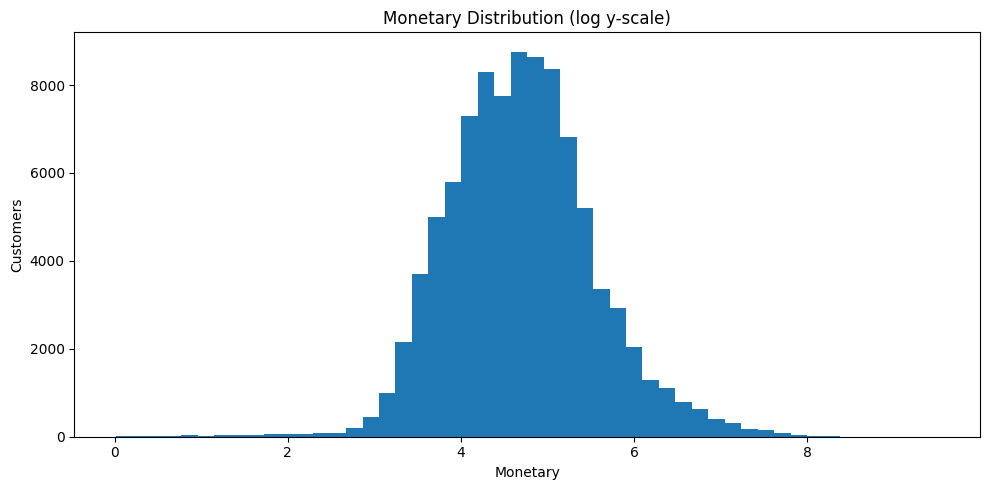

In [81]:
rfm_new["log_monetary"] = np.log1p(rfm_new["monetary"])

plt.figure(figsize=(10, 5))
plt.hist(rfm_new["log_monetary"].values, bins=50)
plt.title("Monetary Distribution (log y-scale)")
plt.xlabel("Monetary")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

Pareto (Revenue Concentration)

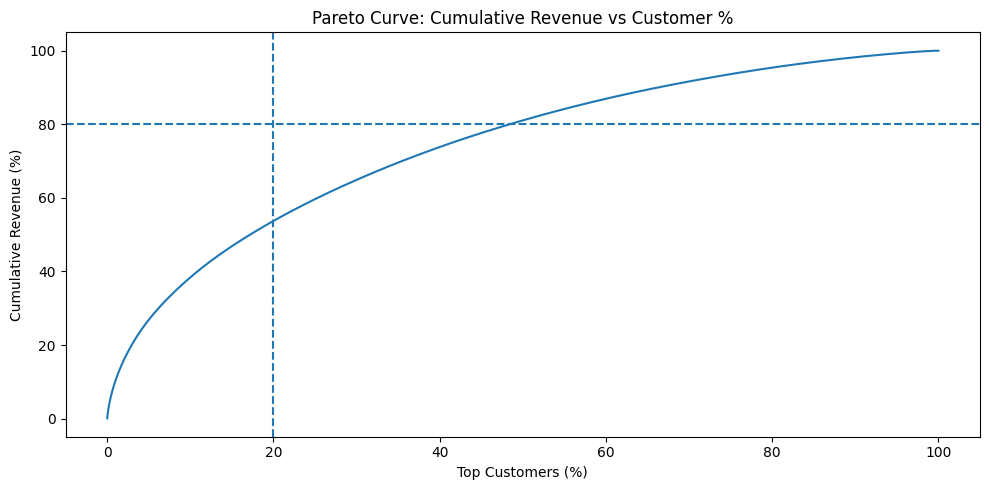

In [84]:
rfm_sorted = rfm_new[["customer_unique_id", "monetary"]].dropna().sort_values("monetary", ascending=False)
rfm_sorted["cum_rev"] = rfm_sorted["monetary"].cumsum()
total_rev = rfm_sorted["monetary"].sum()
rfm_sorted["cum_rev_pct"] = 100 * rfm_sorted["cum_rev"] / total_rev
rfm_sorted["cust_rank_pct"] = 100 * (np.arange(1, len(rfm_sorted) + 1) / len(rfm_sorted))

plt.figure(figsize=(10, 5))
plt.plot(rfm_sorted["cust_rank_pct"], rfm_sorted["cum_rev_pct"])
plt.axhline(80, linestyle="--")
plt.axvline(20, linestyle="--")
plt.title("Pareto Curve: Cumulative Revenue vs Customer %")
plt.xlabel("Top Customers (%)")
plt.ylabel("Cumulative Revenue (%)")
plt.tight_layout()
plt.show()

In [86]:
# Top 10/20 revenue share
top10_share = rfm_sorted.loc[rfm_sorted["cust_rank_pct"] <= 10, "monetary"].sum() / total_rev
top20_share = rfm_sorted.loc[rfm_sorted["cust_rank_pct"] <= 20, "monetary"].sum() / total_rev
print(f"Top 10% revenue share: {top10_share:.2%}")
print(f"Top 20% revenue share: {top20_share:.2%}")

Top 10% revenue share: 38.40%
Top 20% revenue share: 53.74%


Bubble Scatter: Recency vs Monetary

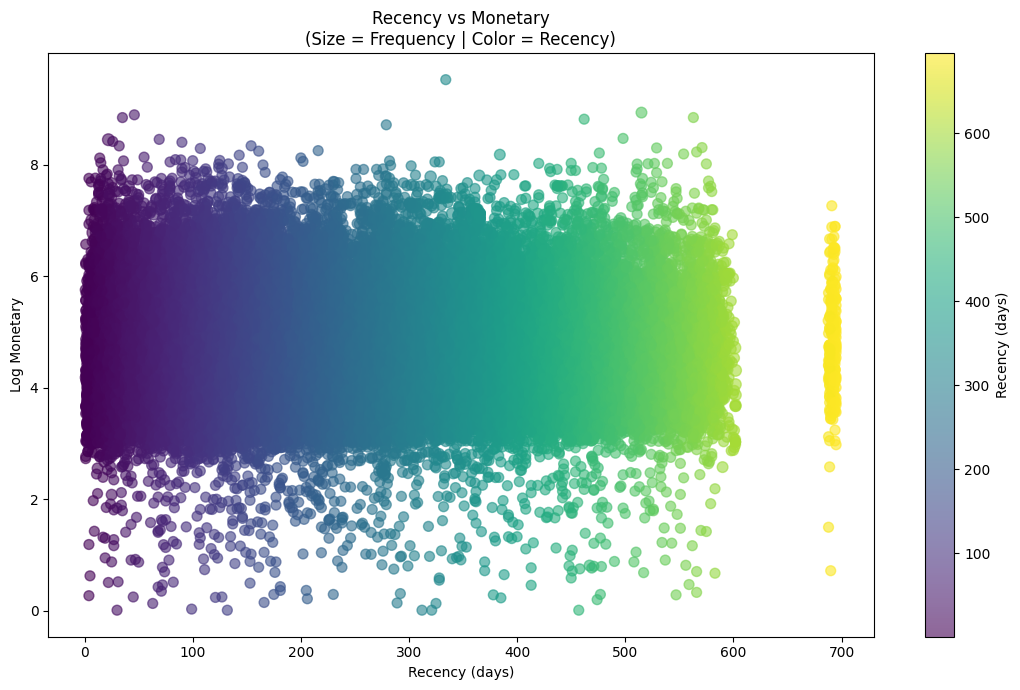

In [89]:
tmp = rfm_new[["recency_days", "log_monetary", "frequency"]].dropna().copy()

# size
sizes = np.sqrt(tmp["frequency"])
sizes = 30 + 80 * (sizes / sizes.max())

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    tmp["recency_days"],
    tmp["log_monetary"],
    s=sizes,
    c=tmp["recency_days"],
    cmap="viridis",   # modern gradient
    alpha=0.6
)

plt.colorbar(scatter, label="Recency (days)")
plt.title("Recency vs Monetary\n(Size = Frequency | Color = Recency)")
plt.xlabel("Recency (days)")
plt.ylabel("Log Monetary")
plt.tight_layout()
plt.show()



## Customer Lifetime Value Modeling

Customer Lifetime Value (CLV) estimates the expected future value that a customer will generate for the business.

In non-contractual settings such as e-commerce, probabilistic models are commonly used to estimate future transactions and revenue.

Two probabilistic models are used:

- **BG/NBD model** → predicts purchase frequency
- **Gamma-Gamma model** → predicts monetary value

Together these models estimate the expected future revenue of each customer.

In [92]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP


In [94]:
len(df_all["order_id"].value_counts())

96478

In [96]:
df_all.shape

(96478, 30)

In our dataset, order_ids are unique.

In [99]:
len(df_all["customer_unique_id"].value_counts())

93358

In [101]:
analysis_date = df_all["purchase_ts"].max()

cltv_c = (df_all.groupby("customer_unique_id", as_index=False)
       .agg(first_purchase = ("purchase_ts","min"),
            last_purchase =("purchase_ts","max"),
            total_transaction = ("order_id","nunique"),
            total_unit = ("item_count", "sum"),
            total_price = ("total_payment","sum")
            ))

In [103]:
cltv_c.head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,141.90000
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,27.19000
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,86.22000
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,43.62000
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,196.89000


In [105]:
# Average Order Value (average_order_value = total_price / total_transaction)

cltv_c["average_order_value"] = cltv_c["total_price"] / cltv_c["total_transaction"]
cltv_c.head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,141.90000,141.90000
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,27.19000,27.19000
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,86.22000,86.22000
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,43.62000,43.62000
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,196.89000,196.89000


In [107]:
## Purchase Frequency (total_transaction / total_number_of_customers)
cltv_c["purchase_frequency"] = cltv_c["total_transaction"] / cltv_c.shape[0]
cltv_c.head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,141.90000,141.90000,0.00001
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,27.19000,27.19000,0.00001
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,86.22000,86.22000,0.00001
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,43.62000,43.62000,0.00001
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,196.89000,196.89000,0.00001


In [109]:
cltv_c.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase,93358,2018-01-01 12:18:32.380503296,2016-09-15 12:16:38,2017-09-13 15:41:22.500000,2018-01-20 06:48:07,2018-05-05 14:13:38.249999872,2018-08-29 15:00:37,NaN
last_purchase,93358,2018-01-04 03:47:36.045363200,2016-09-15 12:16:38,2017-09-17 18:25:15,2018-01-23 00:12:12.500000,2018-05-07 17:22:34.750000128,2018-08-29 15:00:37,NaN
total_transaction,93358.00000,1.03342,1.00000,1.00000,1.00000,1.00000,15.00000,0.20910
total_unit,93358.00000,1.18037,1.00000,1.00000,1.00000,1.00000,24.00000,0.62086
total_price,93358.00000,162.48219,0.00000,61.32000,106.10000,180.04000,13664.08000,223.92195
average_order_value,93358.00000,157.68395,0.00000,60.49250,103.55000,174.81000,13664.08000,217.17680
purchase_frequency,93358.00000,0.00001,0.00001,0.00001,0.00001,0.00001,0.00016,0.00000


In [111]:
## Repeat Rate & Churn Rate (number of customers making multiple purchases / total customers)
repeat_rate = cltv_c[cltv_c["total_transaction"]>1].shape[0] / cltv_c.shape[0]
churn_rate = 1-repeat_rate
churn_rate

0.9699972150217443

In [113]:
## Profit Margin (It was taken as 10%.)
cltv_c["profit_margin"] = cltv_c["total_price"] * 0.10
cltv_c.head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,141.90000,141.90000,0.00001,14.19000
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,27.19000,27.19000,0.00001,2.71900
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,86.22000,86.22000,0.00001,8.62200
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,43.62000,43.62000,0.00001,4.36200
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,196.89000,196.89000,0.00001,19.68900


In [115]:
## Customer Value (customer_value = average_order_value * purchase_frequency)
cltv_c["customer_value"] = cltv_c["average_order_value"] * cltv_c["purchase_frequency"]
cltv_c.head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,141.90000,141.90000,0.00001,14.19000,0.00152
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,27.19000,27.19000,0.00001,2.71900,0.00029
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,86.22000,86.22000,0.00001,8.62200,0.00092
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,43.62000,43.62000,0.00001,4.36200,0.00047
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,196.89000,196.89000,0.00001,19.68900,0.00211


In [117]:
## Customer Lifetime Value (CLTV = (customer_value / churn_rate) * profit_margin)
cltv_c["cltv"] = (cltv_c["customer_value"] / churn_rate) * cltv_c["profit_margin"]
cltv_c.sort_values(by="cltv", ascending=False).head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv
3724,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,2017-09-29 15:24:52,1,8,13664.08000,13664.08000,0.00001,1366.40800,0.14636,206.17631
79636,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:40,2017-04-01 15:58:41,2,2,7571.63000,3785.81500,0.00002,757.16300,0.08110,63.30773
43168,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,2018-07-15 14:49:44,1,4,7274.88000,7274.88000,0.00001,727.48800,0.07792,58.44262
80463,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,2017-02-12 20:37:36,1,1,6929.31000,6929.31000,0.00001,692.93100,0.07422,53.02223
25436,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,2018-07-25 18:10:17,1,1,6922.21000,6922.21000,0.00001,692.22100,0.07415,52.91362


In [119]:
cltv_c.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase,93358,2018-01-01 12:18:32.380503296,2016-09-15 12:16:38,2017-09-13 15:41:22.500000,2018-01-20 06:48:07,2018-05-05 14:13:38.249999872,2018-08-29 15:00:37,NaN
last_purchase,93358,2018-01-04 03:47:36.045363200,2016-09-15 12:16:38,2017-09-17 18:25:15,2018-01-23 00:12:12.500000,2018-05-07 17:22:34.750000128,2018-08-29 15:00:37,NaN
total_transaction,93358.00000,1.03342,1.00000,1.00000,1.00000,1.00000,15.00000,0.20910
total_unit,93358.00000,1.18037,1.00000,1.00000,1.00000,1.00000,24.00000,0.62086
total_price,93358.00000,162.48219,0.00000,61.32000,106.10000,180.04000,13664.08000,223.92195
average_order_value,93358.00000,157.68395,0.00000,60.49250,103.55000,174.81000,13664.08000,217.17680
purchase_frequency,93358.00000,0.00001,0.00001,0.00001,0.00001,0.00001,0.00016,0.00000
profit_margin,93358.00000,16.24822,0.00000,6.13200,10.61000,18.00400,1366.40800,22.39220
customer_value,93358.00000,0.00174,0.00000,0.00066,0.00114,0.00193,0.14636,0.00240
cltv,93358.00000,0.08452,0.00000,0.00415,0.01243,0.03579,206.17631,0.91989


Total price and profit margin appear to be important criteria for ranking.

In [122]:
## Creating Segments

cltv_c.sort_values(by="cltv", ascending=False).head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv
3724,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,2017-09-29 15:24:52,1,8,13664.08000,13664.08000,0.00001,1366.40800,0.14636,206.17631
79636,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:40,2017-04-01 15:58:41,2,2,7571.63000,3785.81500,0.00002,757.16300,0.08110,63.30773
43168,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,2018-07-15 14:49:44,1,4,7274.88000,7274.88000,0.00001,727.48800,0.07792,58.44262
80463,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,2017-02-12 20:37:36,1,1,6929.31000,6929.31000,0.00001,692.93100,0.07422,53.02223
25436,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,2018-07-25 18:10:17,1,1,6922.21000,6922.21000,0.00001,692.22100,0.07415,52.91362


In [124]:
cltv_c.sort_values(by="cltv", ascending=False).tail()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv
54847,967d07493b6792043f97262a0a4b15f8,2018-07-30 17:46:46,2018-07-30 17:46:46,1,1,0.01000,0.01000,0.00001,0.00100,0.00000,0.00000
18525,329932a796b9bc326d71e3b932182cdf,2017-10-22 00:31:28,2017-10-22 00:31:28,1,1,0.01000,0.01000,0.00001,0.00100,0.00000,0.00000
6608,11f78d8517618f460d3a1179f42b6f9f,2017-10-13 12:58:35,2017-10-13 12:58:35,1,1,0.01000,0.01000,0.00001,0.00100,0.00000,0.00000
84190,e6915acf7e23a8c5a80bead3b5aea8c9,2017-05-30 11:00:28,2017-05-30 11:00:28,1,1,0.01000,0.01000,0.00001,0.00100,0.00000,0.00000
47882,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38,2016-09-15 12:16:38,1,3,0.00000,0.00000,0.00001,0.00000,0.00000,0.00000


In [126]:
cltv_c["segment"] = pd.qcut(cltv_c["cltv"], 4, labels=["D","C","B","A"]) # from small to big
cltv_c.sort_values(by="cltv", ascending=False).head()

,customer_unique_id,first_purchase,last_purchase,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv,segment
3724,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,2017-09-29 15:24:52,1,8,13664.08000,13664.08000,0.00001,1366.40800,0.14636,206.17631,A
79636,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:40,2017-04-01 15:58:41,2,2,7571.63000,3785.81500,0.00002,757.16300,0.08110,63.30773,A
43168,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,2018-07-15 14:49:44,1,4,7274.88000,7274.88000,0.00001,727.48800,0.07792,58.44262,A
80463,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,2017-02-12 20:37:36,1,1,6929.31000,6929.31000,0.00001,692.93100,0.07422,53.02223,A
25436,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,2018-07-25 18:10:17,1,1,6922.21000,6922.21000,0.00001,692.22100,0.07415,52.91362,A


In [128]:
cltv_c.iloc[:, 3:].groupby("segment").agg({"count", "mean", "sum"})

total_transaction                total_unit                 \
                      sum    mean  count        sum    mean  count   
segment                                                              
D                   23416 1.00321  23341      24014 1.02883  23341   
C                   23643 1.01294  23341      25424 1.08924  23341   
B                   24061 1.03102  23337      27450 1.17624  23337   
A                   25358 1.08651  23339      33309 1.42718  23339   

          total_price                  average_order_value                   \
                  sum      mean  count                 sum      mean  count   
segment                                                                       
D        964145.29000  41.30694  23341        962544.87667  41.23837  23341   
C       1908320.74000  81.75831  23341       1895530.68500  81.21035  23341   
B       3245455.67000 139.06910  23337       3195187.32000 136.91508  23337   
A       9051090.73000 387.80971  23339       8667795.27051 371.38675  23339   

        purchase_frequency                profit_margin                  \
                       sum    mean  count           sum     mean  count   
segment                                                                   
D                  0.25082 0.00001  23341   96414.52900  4.13069  23341   
C                  0.25325 0.00001  23341  190832.07400  8.17583  23341   
B                  0.25773 0.00001  23337  324545.56700 13.90691  23337   
A                  0.27162 0.00001  23339  905109.07300 38.78097  23339   

        customer_value                      cltv                 
                   sum    mean  count        sum    mean  count  
segment                                                          
D             10.32740 0.00044  23341   48.03854 0.00206  23341  
C             20.44089 0.00088  23341  176.67491 0.00757  23341  
B             34.76355 0.00149  23337  509.88804 0.02185  23337  
A             96.95035 0.00415  23339 7156.24249 0.30662  23339

* Customers in segments A and B have a higher average order volume compared to other segments.
* Customers in segments A and B purchase an average of a higher number of products compared to other segments.
* Customers in segments A and B pay an average of higher amounts compared to other segments.
* Customers in segments A and B pay more on average per order compared to other segments.
* The average net profit generated from customers in segments A and B is higher than that generated from other segments.

## Creating a Reusable CLV

In [132]:
def create_cltv_c(dataframe, profit = 0.10, csv=False):
    analysis_date = dataframe["purchase_ts"].max()

    cltv_c = (dataframe.groupby("customer_unique_id", as_index=False)
           .agg(total_transaction = ("order_id","nunique"),
                total_unit = ("item_count", "sum"),
                total_price = ("total_payment","sum")
                ))

    # Average Order Value (average_order_value = total_price / total_transaction)
    cltv_c["average_order_value"] = cltv_c["total_price"] / cltv_c["total_transaction"]

    ## Purchase Frequency (total_transaction / total_number_of_customers)
    cltv_c["purchase_frequency"] = cltv_c["total_transaction"] / cltv_c.shape[0]

    ## Repeat Rate & Churn Rate (number of customers making multiple purchases / total customers)
    repeat_rate = cltv_c[cltv_c["total_transaction"]>1].shape[0] / cltv_c.shape[0]
    churn_rate = 1-repeat_rate

    ## Profit Margin (It was taken as 10%.)
    cltv_c["profit_margin"] = cltv_c["total_price"] * profit

    ## Customer Value (customer_value = average_order_value * purchase_frequency)
    cltv_c["customer_value"] = cltv_c["average_order_value"] * cltv_c["purchase_frequency"]

    ## Customer Lifetime Value (CLTV = (customer_value / churn_rate) * profit_margin)
    cltv_c["cltv"] = (cltv_c["customer_value"] / churn_rate) * cltv_c["profit_margin"]

    # segment
    cltv_c["segment"] = pd.qcut(cltv_c["cltv"], 4, labels=["D","C","B","A"]) # from small to big
    
    if csv:
        cltv_c.to_csv("cltc_c.csv", index=False)
        print("The file has been saved.")

    return cltv_c

In [134]:
clv_c2 = create_cltv_c(df_all, csv=True)

clv_c2.head()

The file has been saved.


,customer_unique_id,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90000,141.90000,0.00001,14.19000,0.00152,0.02224,B
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19000,27.19000,0.00001,2.71900,0.00029,0.00082,D
2,0000f46a3911fa3c0805444483337064,1,1,86.22000,86.22000,0.00001,8.62200,0.00092,0.00821,C
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62000,43.62000,0.00001,4.36200,0.00047,0.00210,D
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89000,196.89000,0.00001,19.68900,0.00211,0.04281,A


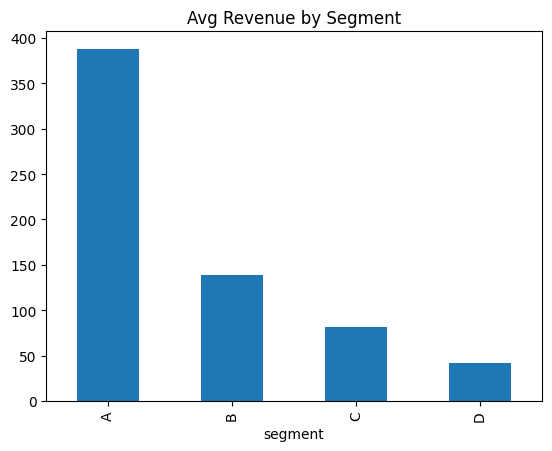

In [135]:
clv_c2.groupby("segment")["total_price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Avg Revenue by Segment")
plt.show()

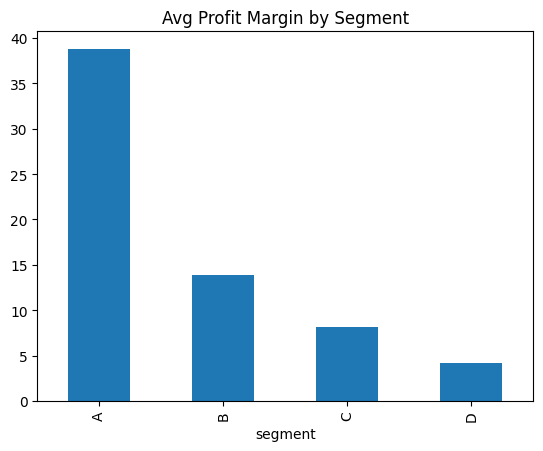

In [138]:
clv_c2.groupby("segment")["profit_margin"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Avg Profit Margin by Segment")
plt.show()

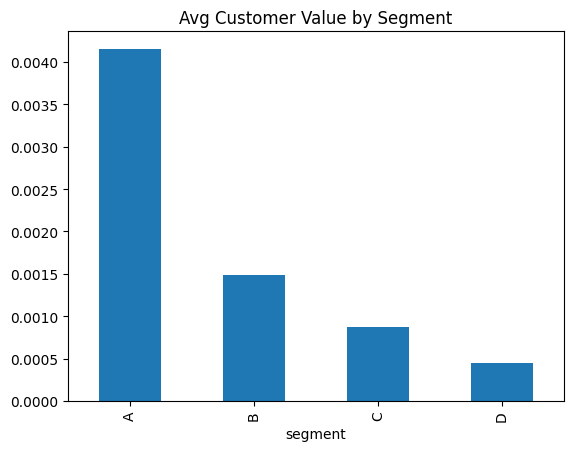

In [140]:
clv_c2.groupby("segment")["customer_value"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Avg Customer Value by Segment")
plt.show()

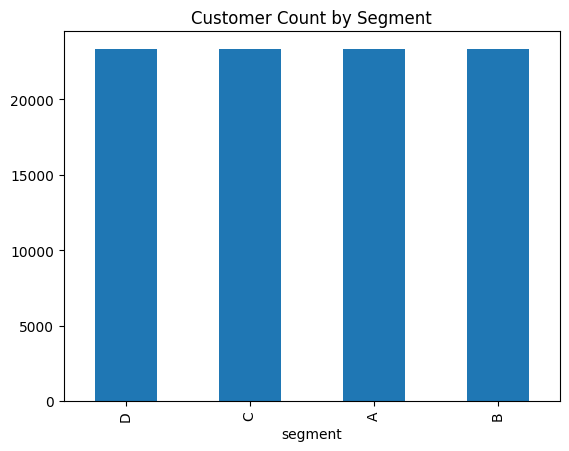

In [142]:
clv_c2.groupby("segment")["customer_unique_id"].count().sort_values(ascending=False).plot(kind="bar")
plt.title("Customer Count by Segment")
plt.show()

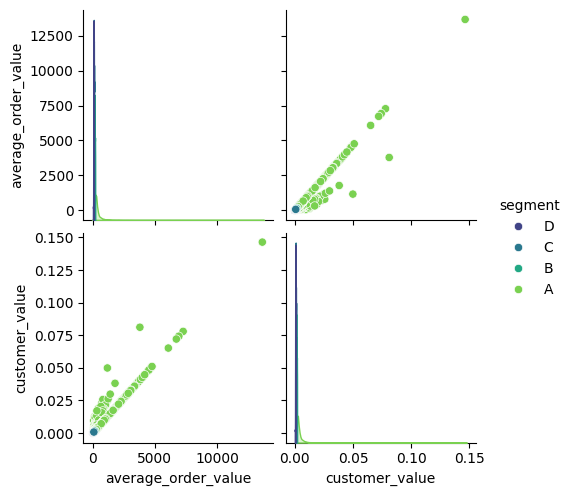

In [144]:
a = clv_c2[["average_order_value", "customer_value","segment"]]

# Piarplot
sns.pairplot(a, palette="viridis" ,diag_kind="kde", markers="o",hue="segment")
plt.show()

## CLTV Prediction

The tasks we will focus on in this section are as follows:
* Expected 1-week purchases for all customers.
* Customers we expect to make the most purchases in 1 month.
* Expected sales for the entire company in 3 months.
* Expected Average Profit with Gamma-Gamma Model
* Calculation of CLTV with Bg-NBD and Gamma-Gamma models.

The models we will be building are probabilistic and statistical models. Therefore, we will suppress outliers.

In [146]:
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [147]:
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    # dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

### Data Preprocessing

In [149]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP


In [150]:
df_copy = df_all.copy()

In [151]:
df_copy.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
order_status                   0
purchase_ts                    0
approved_ts                   14
carrier_ts                     2
delivered_ts                   8
est_delivery_ts                0
days_to_deliver                8
is_late                        0
total_price                    0
total_freight                  0
total_revenue                  0
item_count                     0
total_payment                  1
payment_count                  1
max_installments               1
payment_minus_revenue          1
review_score                1107
review_comment_title        1107
review_comment_message      1107
review_creation_date        1108
main_category_by_item          0
main_category_by_revenue       0
category_count                 0
order_type                     0
all_categories                 0
customer_city                  0
customer_state                 0
dtype: int

In [152]:
df_copy.describe().T

,count,mean,min,25%,50%,75%,max,std
purchase_ts,96478,2018-01-01 23:29:31.939913728,2016-09-15 12:16:38,2017-09-14 09:00:23.249999872,2018-01-20 19:45:45,2018-05-05 18:54:47,2018-08-29 15:00:37,NaN
approved_ts,96464,2018-01-02 10:53:23.338012160,2016-09-15 12:16:38,2017-09-14 14:48:54,2018-01-22 13:50:04,2018-05-06 10:57:24.750000128,2018-08-29 15:10:26,NaN
carrier_ts,96476,2018-01-05 05:01:50.912330496,2016-10-08 10:34:01,2017-09-18 16:46:13.249999872,2018-01-24 16:13:47.500000,2018-05-08 14:35:00,2018-09-11 19:48:28,NaN
delivered_ts,96470,2018-01-14 12:41:33.581683456,2016-10-11 13:46:32,2017-09-25 22:15:09.500000,2018-02-02 19:32:21,2018-05-15 22:54:48.500000,2018-10-17 13:22:46,NaN
est_delivery_ts,96478,2018-01-25 17:09:52.325711616,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
days_to_deliver,96470.00000,12.49685,0.00000,7.00000,10.00000,16.00000,210.00000,9.55507
is_late,96478.00000,0.08112,0.00000,0.00000,0.00000,0.00000,1.00000,0.27302
total_price,96478.00000,137.04159,0.85000,45.90000,86.57500,149.90000,13440.00000,209.04520
total_freight,96478.00000,22.78525,0.00000,13.85000,17.17000,24.01750,1794.96000,21.55920
total_revenue,96478.00000,159.82684,9.59000,61.85000,105.28000,176.26000,13664.08000,218.79422


In [158]:
# Suppressing extreme values
replace_with_thresholds(df_copy, "item_count")
replace_with_thresholds(df_copy, "total_payment")

In [162]:
df_copy.describe().T

,count,mean,min,25%,50%,75%,max,std
purchase_ts,96478,2018-01-01 23:29:31.939913728,2016-09-15 12:16:38,2017-09-14 09:00:23.249999872,2018-01-20 19:45:45,2018-05-05 18:54:47,2018-08-29 15:00:37,NaN
approved_ts,96464,2018-01-02 10:53:23.338012160,2016-09-15 12:16:38,2017-09-14 14:48:54,2018-01-22 13:50:04,2018-05-06 10:57:24.750000128,2018-08-29 15:10:26,NaN
carrier_ts,96476,2018-01-05 05:01:50.912330496,2016-10-08 10:34:01,2017-09-18 16:46:13.249999872,2018-01-24 16:13:47.500000,2018-05-08 14:35:00,2018-09-11 19:48:28,NaN
delivered_ts,96470,2018-01-14 12:41:33.581683456,2016-10-11 13:46:32,2017-09-25 22:15:09.500000,2018-02-02 19:32:21,2018-05-15 22:54:48.500000,2018-10-17 13:22:46,NaN
est_delivery_ts,96478,2018-01-25 17:09:52.325711616,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
days_to_deliver,96470.00000,12.49685,0.00000,7.00000,10.00000,16.00000,210.00000,9.55507
is_late,96478.00000,0.08112,0.00000,0.00000,0.00000,0.00000,1.00000,0.27302
total_price,96478.00000,137.04159,0.85000,45.90000,86.57500,149.90000,13440.00000,209.04520
total_freight,96478.00000,22.78525,0.00000,13.85000,17.17000,24.01750,1794.96000,21.55920
total_revenue,96478.00000,159.82684,9.59000,61.85000,105.28000,176.26000,13664.08000,218.79422


### Preparing the Lifetime Data Structure

* We will prepare the specific data format required by the BG-NBD and Gamma-Gamma models.
* Recency: Time elapsed since the last purchase. Weekly. (User-specific)
* T: Customer's age. Weekly. (How long ago did they make their first purchase before the analysis date?)
* monetary_value = average value of repeat purchases

In [165]:
from lifetimes.utils import summary_data_from_transaction_data

orders = (df_copy.groupby("order_id", as_index=False)
          .agg(customer_unique_id=("customer_unique_id", "first"),
               purchase_ts=("purchase_ts", "min"),
               monetary=("total_payment", "max")))

summary = summary_data_from_transaction_data(
    orders,
    customer_id_col="customer_unique_id",
    datetime_col="purchase_ts",
    monetary_value_col="monetary",
    observation_period_end=orders["purchase_ts"].max()
)
# summary columns: frequency, recency, T, monetary_value
summary.head()

,frequency,recency,T,monetary_value
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,111.00000,0.00000
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,114.00000,0.00000
0000f46a3911fa3c0805444483337064,0.00000,0.00000,537.00000,0.00000
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,321.00000,0.00000
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,288.00000,0.00000


In [166]:
summary_w = summary.copy()
summary_w["recency"] = summary_w["recency"] / 7.0
summary_w["T"] = summary_w["T"] / 7.0

In [169]:
summary_w.describe().T

,count,mean,std,min,25%,50%,75%,max
frequency,93358.00000,0.02389,0.17724,0.00000,0.00000,0.00000,0.00000,14.00000
recency,93358.00000,0.37787,3.57249,0.00000,0.00000,0.00000,0.00000,90.42857
T,93358.00000,34.30342,21.87183,0.00000,16.57143,31.57143,50.00000,101.85714
monetary_value,93358.00000,3.18878,31.66398,0.00000,0.00000,0.00000,0.00000,2405.28000


### BG/NBD Model

The BG/NBD (Beta-Geometric / Negative Binomial Distribution) model predicts:

- the probability that a customer is still active
- the expected number of future purchases

This model is widely used in customer analytics for non-contractual businesses such as retail and e-commerce.

In [172]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary_w["frequency"], summary_w["recency"], summary_w["T"])
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.01628,0.00082,0.01467,0.01790
alpha,10.09385,0.88621,8.35686,11.83083
a,0.10298,0.01813,0.06744,0.13852
b,0.01802,0.00350,0.01116,0.02489


* r = 0.01628: The vast majority of customers shop rarely. A small group of customers are frequent shoppers.


In [175]:
# Expected purchase rate:
bgf.summary.loc["r", "coef"] / bgf.summary.loc["alpha", "coef"]

0.0016131657764169196

* The average customer doesn't shop very often.

* The culture of repeat shoppers may be weak.

In [178]:
# Churn probability expectation:
bgf.summary.loc["a", "coef"] / (bgf.summary.loc["a", "coef"] + bgf.summary.loc["b", "coef"])

0.8510610992948866

* The probability of the average customer being "dead" after the transaction is approximately 85%.

Who are the top 10 customers we expect to make the most purchases from within the next week?

In [182]:
bgf.conditional_expected_number_of_purchases_up_to_time(1,
                                                        summary_w["frequency"],
                                                        summary_w["recency"],
                                                        summary_w["T"]).sort_values(ascending=False).head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455   0.19118
ca77025e7201e3b30c44b472ff346268   0.09731
e0836a97eaae86ac4adc26fbb334a527   0.09457
bc3e7032668d3f411c227eec09221362   0.08561
394ac4de8f3acb14253c177f0e15bc58   0.08412
6469f99c1f9dfae7733b25662e7f1782   0.07998
6a9e15d6fa8ce1cabf193c21aa577f64   0.07820
dc813062e0fc23409cd255f7f53c7074   0.06904
cfa69922f9968e0e6271647abda09b09   0.06880
fe81bb32c243a86b2f86fbf053fe6140   0.06838
dtype: float64

In [184]:
bgf.predict(1,
            summary_w["frequency"],
            summary_w["recency"],
            summary_w["T"]).sort_values(ascending=False).head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455   0.19118
ca77025e7201e3b30c44b472ff346268   0.09731
e0836a97eaae86ac4adc26fbb334a527   0.09457
bc3e7032668d3f411c227eec09221362   0.08561
394ac4de8f3acb14253c177f0e15bc58   0.08412
6469f99c1f9dfae7733b25662e7f1782   0.07998
6a9e15d6fa8ce1cabf193c21aa577f64   0.07820
dc813062e0fc23409cd255f7f53c7074   0.06904
cfa69922f9968e0e6271647abda09b09   0.06880
fe81bb32c243a86b2f86fbf053fe6140   0.06838
dtype: float64

In [186]:
# Expected 1-week purchase period for all customers:
summary_w["expected_purc_1_week"] = bgf.predict(1,
                                              summary_w["frequency"],
                                              summary_w["recency"],
                                              summary_w["T"])

summary_w.head()

,frequency,recency,T,monetary_value,expected_purc_1_week
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061
0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032


In [188]:
# Customers we expect to make the most purchases within the next month:

bgf.predict(4,
            summary_w["frequency"],
            summary_w["recency"],
            summary_w["T"]).sort_values(ascending=False).head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455   0.76303
ca77025e7201e3b30c44b472ff346268   0.38805
e0836a97eaae86ac4adc26fbb334a527   0.37440
bc3e7032668d3f411c227eec09221362   0.33920
394ac4de8f3acb14253c177f0e15bc58   0.33517
6469f99c1f9dfae7733b25662e7f1782   0.31896
6a9e15d6fa8ce1cabf193c21aa577f64   0.31003
dc813062e0fc23409cd255f7f53c7074   0.27549
cfa69922f9968e0e6271647abda09b09   0.27304
fe81bb32c243a86b2f86fbf053fe6140   0.27262
dtype: float64

In [190]:
summary_w["expected_purc_1_month"] = bgf.predict(4,
                                              summary_w["frequency"],
                                              summary_w["recency"],
                                              summary_w["T"])

summary_w.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232
0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123


In [192]:
# Total expected purchases within 1 month:
bgf.predict(4,
            summary_w["frequency"],
            summary_w["recency"],
            summary_w["T"]).sum()

205.53035529157975

* The total number of expected purchases across all customer groups in the next 4 weeks is approximately 205.

In [195]:
# Expected Sales Figure for the Entire Company in 3 Months
bgf.predict(4*3,
            summary_w["frequency"],
            summary_w["recency"],
            summary_w["T"]).sum()

563.9361328637892

In [197]:
summary_w["expected_purc_3_month"] = bgf.predict(4*3,
                                              summary_w["frequency"],
                                              summary_w["recency"],
                                              summary_w["T"])

summary_w.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


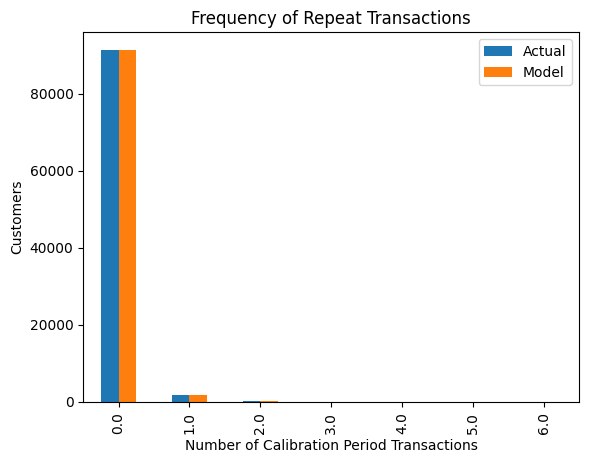

In [199]:
plot_period_transactions(bgf)
plt.show()

In [200]:
# Repeat Rate
repeat_rate = (summary_w["frequency"] > 0).mean()

print(f"Repeat rate: {repeat_rate:.2%}")

Repeat rate: 2.16%


Gamma-Gamma only works for repeat customers:

### Gamma-Gamma Model

The Gamma-Gamma model estimates the expected average profit per transaction for each customer.

A key assumption of the model is that purchase frequency and monetary value are independent.

This assumption was tested before applying the model.

In [205]:
from lifetimes import GammaGammaFitter

gg = summary_w[(summary_w["frequency"] > 0) & (summary_w["monetary_value"] > 0)].copy()

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(gg["frequency"], gg["monetary_value"])
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,4.02788,0.10950,3.81326,4.24251
q,0.49538,0.01307,0.46975,0.52101
v,3.76912,0.11133,3.55092,3.98732


In [207]:
summary_w[summary_w["frequency"] > 0][["frequency","monetary_value"]].corr()

,frequency,monetary_value
frequency,1.00000,0.00322
monetary_value,0.00322,1.00000


* The most critical assumption of the Gamma-Gamma model is that Frequency and Monetary are independent.

In [210]:
# Expected Average Profit
ggf.conditional_expected_average_profit(gg["frequency"],
                                        gg["monetary_value"]).sort_values(ascending=False).head(10)

customer_unique_id
c8460e4251689ba205045f3ea17884a1   2754.08537
a1044dd75b74fbc485b040575a14acf0   1890.83611
012a218df8995d3ec3bb221828360c86   1645.94587
da1e7179b9c5a1494d78528cbcf05aa0   1595.43819
6e26bbeaa107ec34112c64e1ee31c0f5   1577.90111
f0daba1cfcc18d5a3229e1a911313e3e   1546.14232
5457ae2c352c18e3bf5cba68301d96a8   1418.79848
ecdbc4bf2201c807294c7d8c4b777032   1402.54182
0341bbd5c969923a0f801b9e2d10a7b8   1233.91612
4711348768db55c57a67aba080ead566   1193.89181
dtype: float64

In [212]:
gg["expected_average_profit"] = ggf.conditional_expected_average_profit(gg["frequency"],
                                                                        gg["monetary_value"])
gg.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit
customer_unique_id,,,,,,,,
004288347e5e88a27ded2bb23747066c,1.00000,24.42857,56.85714,103.28000,0.00124,0.00495,0.01470,122.38124
00a39521eb40f7012db50455bf083460,1.00000,1.57143,14.00000,26.78000,0.00325,0.01285,0.03766,34.92452
011575986092c30523ecb71ff10cb473,1.00000,8.57143,27.57143,80.32000,0.00213,0.00844,0.02492,96.13279
011b4adcd54683b480c4d841250a987f,1.00000,25.28571,53.14286,149.88000,0.00142,0.00565,0.01678,175.65553
012452d40dafae4df401bced74cdb490,1.00000,47.14286,62.42857,42.50000,0.00169,0.00675,0.02005,52.89602


## CLV Calculation

Customer Lifetime Value is calculated by combining:

Expected number of future purchases (BG/NBD)

and

Expected profit per purchase (Gamma-Gamma)

The resulting CLV metric helps prioritize high-value customers.

Let's estimate the revenue that customers will generate in 3 weeks and 3 months.

In [216]:
# There may be various discounts on products sold over time -> 0.01
cltv = ggf.customer_lifetime_value(bgf,
                                   gg["frequency"],
                                   gg["recency"],
                                   gg["T"],
                                   gg["monetary_value"],
                                   time=3,
                                   freq="W",
                                   discount_rate=0.01)
cltv.head()

customer_unique_id
004288347e5e88a27ded2bb23747066c   1.91370
00a39521eb40f7012db50455bf083460   1.39705
011575986092c30523ecb71ff10cb473   2.54620
011b4adcd54683b480c4d841250a987f   3.13453
012452d40dafae4df401bced74cdb490   1.12822
Name: clv, dtype: float64

In [218]:
cltv_12w = ggf.customer_lifetime_value(
    bgf,
    gg["frequency"],
    gg["recency"],
    gg["T"],
    gg["monetary_value"],
    time=12,
    freq="W",
    discount_rate=0.01
)

In [220]:
cltv_12w.head()

customer_unique_id
004288347e5e88a27ded2bb23747066c    7.06036
00a39521eb40f7012db50455bf083460    4.99819
011575986092c30523ecb71ff10cb473    9.24057
011b4adcd54683b480c4d841250a987f   11.54726
012452d40dafae4df401bced74cdb490    4.17088
Name: clv, dtype: float64

In [222]:
cltv = cltv.reset_index()
cltv.head()

,customer_unique_id,clv
0,004288347e5e88a27ded2bb23747066c,1.91370
1,00a39521eb40f7012db50455bf083460,1.39705
2,011575986092c30523ecb71ff10cb473,2.54620
3,011b4adcd54683b480c4d841250a987f,3.13453
4,012452d40dafae4df401bced74cdb490,1.12822


In [224]:
summary_w.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


In [226]:
gg.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit
customer_unique_id,,,,,,,,
004288347e5e88a27ded2bb23747066c,1.00000,24.42857,56.85714,103.28000,0.00124,0.00495,0.01470,122.38124
00a39521eb40f7012db50455bf083460,1.00000,1.57143,14.00000,26.78000,0.00325,0.01285,0.03766,34.92452
011575986092c30523ecb71ff10cb473,1.00000,8.57143,27.57143,80.32000,0.00213,0.00844,0.02492,96.13279
011b4adcd54683b480c4d841250a987f,1.00000,25.28571,53.14286,149.88000,0.00142,0.00565,0.01678,175.65553
012452d40dafae4df401bced74cdb490,1.00000,47.14286,62.42857,42.50000,0.00169,0.00675,0.02005,52.89602


In [228]:
cltv_final = gg.merge(cltv, on = "customer_unique_id", how = "left")
cltv_final.sort_values(by="clv", ascending=False).head(10)

,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv
459,397b44d5bb99eabf54ea9c2b41ebb905,3.00000,22.42857,32.85714,476.64000,0.06271,0.24975,0.74126,498.72333,393.18886
326,297ec5afd18366f5ba27520cc4954151,2.00000,12.14286,27.71429,701.16000,0.04110,0.16351,0.48413,750.02685,386.10601
2010,fe81bb32c243a86b2f86fbf053fe6140,4.00000,34.57143,44.42857,381.74500,0.06838,0.27262,0.81113,395.06074,340.91433
1584,c8460e4251689ba205045f3ea17884a1,1.00000,0.14286,3.14286,2405.28000,0.00906,0.03559,0.10299,2754.08537,300.96004
629,4facc2e6fbc2bffab2fea92d2b4aa7e4,3.00000,60.14286,62.42857,532.32000,0.03934,0.15695,0.46770,556.82989,277.11043
241,1da09dd64e235e7c2f29a4faff33535c,2.00000,35.14286,68.00000,845.00000,0.01978,0.07890,0.23507,903.47923,225.97756
68,08e5b38d7948d37fbb2a59fc5e175ab1,2.00000,9.71429,25.57143,350.71500,0.04239,0.16856,0.49875,376.16269,199.47638
1605,ca77025e7201e3b30c44b472ff346268,6.00000,33.57143,46.28571,138.94167,0.09731,0.38805,1.15538,142.54626,175.22697
1060,86df00dc5fd68f4dd5d5945ca19f3ed6,2.00000,18.14286,63.85714,767.94000,0.01598,0.06373,0.18980,821.26955,165.84638
458,394ac4de8f3acb14253c177f0e15bc58,4.00000,33.71429,35.71429,149.28250,0.08412,0.33517,0.99588,155.08201,164.28284


* The customer is new, but has a low recency level. They've made three purchases. They show potential. The algorithm detected them.
* An old client has high recency and T high monetary value, low frequency but high frequency, potential.

## CLV Segmentation

Customers are segmented based on their predicted lifetime value.

Segments are typically defined as:

A → High value customers  
B → Medium-high value customers  
C → Medium value customers  
D → Low value customers

This segmentation helps marketing teams focus on the most profitable customers.

This segmentation allows marketing teams to prioritize high-value customers and design targeted retention strategies.

In [232]:
cltv_final["segment"] = pd.qcut(cltv_final["clv"], 4, labels=["D", "C", "B", "A"])
cltv_final.sort_values(by="clv", ascending=False).head(20)

,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv,segment
459,397b44d5bb99eabf54ea9c2b41ebb905,3.00000,22.42857,32.85714,476.64000,0.06271,0.24975,0.74126,498.72333,393.18886,A
326,297ec5afd18366f5ba27520cc4954151,2.00000,12.14286,27.71429,701.16000,0.04110,0.16351,0.48413,750.02685,386.10601,A
2010,fe81bb32c243a86b2f86fbf053fe6140,4.00000,34.57143,44.42857,381.74500,0.06838,0.27262,0.81113,395.06074,340.91433,A
1584,c8460e4251689ba205045f3ea17884a1,1.00000,0.14286,3.14286,2405.28000,0.00906,0.03559,0.10299,2754.08537,300.96004,A
629,4facc2e6fbc2bffab2fea92d2b4aa7e4,3.00000,60.14286,62.42857,532.32000,0.03934,0.15695,0.46770,556.82989,277.11043,A
241,1da09dd64e235e7c2f29a4faff33535c,2.00000,35.14286,68.00000,845.00000,0.01978,0.07890,0.23507,903.47923,225.97756,A
68,08e5b38d7948d37fbb2a59fc5e175ab1,2.00000,9.71429,25.57143,350.71500,0.04239,0.16856,0.49875,376.16269,199.47638,A
1605,ca77025e7201e3b30c44b472ff346268,6.00000,33.57143,46.28571,138.94167,0.09731,0.38805,1.15538,142.54626,175.22697,A
1060,86df00dc5fd68f4dd5d5945ca19f3ed6,2.00000,18.14286,63.85714,767.94000,0.01598,0.06373,0.18980,821.26955,165.84638,A
458,394ac4de8f3acb14253c177f0e15bc58,4.00000,33.71429,35.71429,149.28250,0.08412,0.33517,0.99588,155.08201,164.28284,A


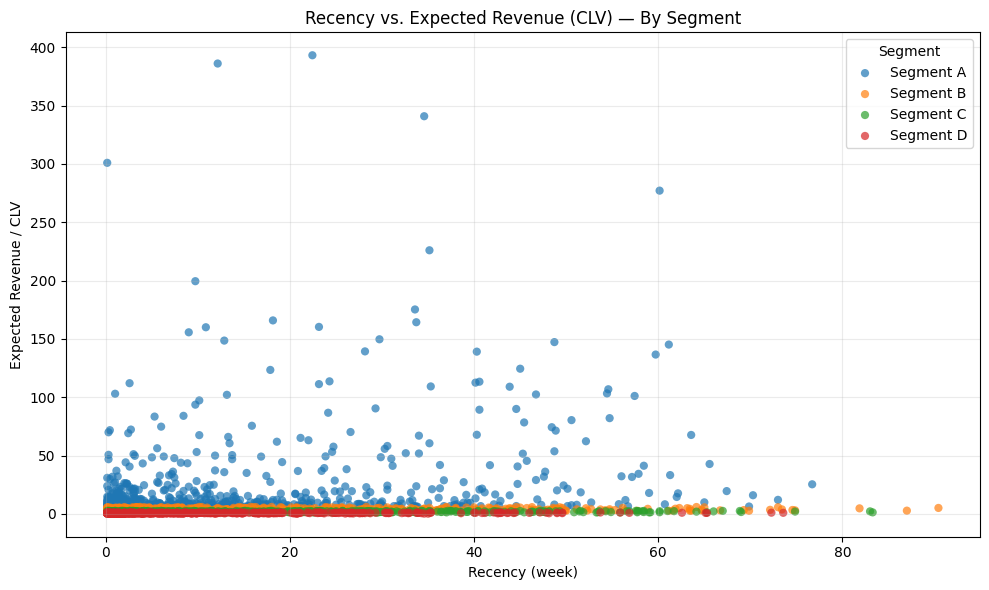

In [234]:

df_c = cltv_final.copy()

df_c = df_c.dropna(subset=["recency", "clv", "segment"])

segments = sorted(df_c["segment"].unique())

cmap = plt.get_cmap("tab10")
color_map = {seg: cmap(i % 10) for i, seg in enumerate(segments)}

plt.figure(figsize=(10, 6))

for seg in segments:
    d = df_c[df_c["segment"] == seg]
    plt.scatter(
        d["recency"],
        d["clv"],
        s=35,
        alpha=0.7,
        label=f"Segment {seg}",
        c=[color_map[seg]],
        edgecolors="none"
    )

plt.title("Recency vs. Expected Revenue (CLV) — By Segment")
plt.xlabel("Recency (week)")   # recency senin tablonda haftalık görünüyor
plt.ylabel("Expected Revenue / CLV")
plt.legend(title="Segment")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [236]:
cltv_final.iloc[:,1:].groupby("segment").agg(
    {"count", "mean", "sum"}
)

frequency                   recency                          T  \
              sum    mean count         sum     mean count         sum   
segment                                                                  
D       504.00000 1.00000   504  5772.85714 11.45408   504 28762.57143   
C       504.00000 1.00000   504  9590.00000 19.02778   504 24459.00000   
B       506.00000 1.00596   503 10509.00000 20.89264   503 20195.85714   
A       716.00000 1.42063   504  9405.28571 18.66128   504 16877.71429   

                       monetary_value                 expected_purc_1_week  \
            mean count            sum      mean count                  sum   
segment                                                                      
D       57.06859   504    31349.66000  62.20171   504              0.43708   
C       48.52976   504    54524.26000 108.18306   504              0.77174   
B       40.15081   503    75593.78000 150.28584   503              1.16268   
A       33.48753   504   136229.97574 270.29757   504              6.41593   

                      expected_purc_1_month                \
           mean count                   sum    mean count   
segment                                                     
D       0.00087   504               1.73986 0.00345   504   
C       0.00153   504               3.06890 0.00609   504   
B       0.00231   503               4.61664 0.00918   503   
A       0.01273   504              25.51604 0.05063   504   

        expected_purc_3_month               expected_average_profit            \
                          sum    mean count                     sum      mean   
segment                                                                         
D                     5.15867 0.01024   504             38011.43017  75.41950   
C                     9.07938 0.01801   504             64505.21409 127.98654   
B                    13.61829 0.02707   503             88572.23742 176.08795   
A                    75.54164 0.14988   504            155636.24450 308.80207   

                      clv                 
        count         sum     mean count  
segment                                   
D         504   334.64340  0.66398   504  
C         504   915.55947  1.81659   504  
B         503  1948.56133  3.87388   503  
A         504 15228.88198 30.21604   504

## Creating a Reusable Customer Lifetime Value Modeling

In [239]:
def create_cltv_p(dataframe, month = 3, csv=False):
    # 1. Data Preprocessing
    replace_with_thresholds(dataframe, "item_count")
    replace_with_thresholds(dataframe, "total_payment")
    
    orders = (dataframe.groupby("order_id", as_index=False)
              .agg(customer_unique_id=("customer_unique_id", "first"),
                   purchase_ts=("purchase_ts", "min"),
                   monetary=("total_payment", "max")))
    
    summary = summary_data_from_transaction_data(
        orders,
        customer_id_col="customer_unique_id",
        datetime_col="purchase_ts",
        monetary_value_col="monetary",
        observation_period_end=orders["purchase_ts"].max()
    )

    summary_w = summary.copy()
    summary_w["recency"] = summary_w["recency"] / 7.0
    summary_w["T"] = summary_w["T"] / 7.0

    # 2. Building the BG-NBD Model

    bgf = BetaGeoFitter(penalizer_coef=0.01)
    bgf.fit(summary_w["frequency"], summary_w["recency"], summary_w["T"])

    summary_w["expected_purc_1_week"] = bgf.predict(1,
                                                  summary_w["frequency"],
                                                  summary_w["recency"],
                                                  summary_w["T"])

    summary_w["expected_purc_1_month"] = bgf.predict(4,
                                                  summary_w["frequency"],
                                                  summary_w["recency"],
                                                  summary_w["T"])

    summary_w["expected_purc_3_month"] = bgf.predict(4*3,
                                                  summary_w["frequency"],
                                                  summary_w["recency"],
                                                  summary_w["T"])
    # 3.Establishing the GAMMA - GAMMA Model
    gg = summary_w[(summary_w["frequency"] > 0) & (summary_w["monetary_value"] > 0)].copy()
    
    ggf = GammaGammaFitter(penalizer_coef=0.01)
    ggf.fit(gg["frequency"], gg["monetary_value"])

    gg["expected_average_profit"] = ggf.conditional_expected_average_profit(gg["frequency"],
                                                                        gg["monetary_value"])

    # 4. Calculation of CLTV using BG-NBD and GG Model.
    cltv = ggf.customer_lifetime_value(bgf,
                                       gg["frequency"],
                                       gg["recency"],
                                       gg["T"],
                                       gg["monetary_value"],
                                       time=month,
                                       freq="W",
                                       discount_rate=0.01)

    cltv = cltv.reset_index()

    cltv_final = gg.merge(cltv, on = "customer_unique_id", how = "left")

    cltv_final["segment"] = pd.qcut(cltv_final["clv"], 4, labels=["D", "C", "B", "A"])

    if csv:
        cltv_final.to_csv("cltv_p.csv", index=False)
        print("The file has been saved.")

    return cltv_final, summary_w
    

In [241]:
cltv_final_2, nbd_summary = create_cltv_p(df_copy, month = 3, csv=True)
cltv_final_2.head()

The file has been saved.


,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv,segment
0,004288347e5e88a27ded2bb23747066c,1.00000,24.42857,56.85714,103.28000,0.00124,0.00495,0.01470,122.38124,1.91370,C
1,00a39521eb40f7012db50455bf083460,1.00000,1.57143,14.00000,26.78000,0.00325,0.01285,0.03766,34.92452,1.39705,C
2,011575986092c30523ecb71ff10cb473,1.00000,8.57143,27.57143,80.32000,0.00213,0.00844,0.02492,96.13279,2.54620,C
3,011b4adcd54683b480c4d841250a987f,1.00000,25.28571,53.14286,149.88000,0.00142,0.00565,0.01678,175.65553,3.13453,B
4,012452d40dafae4df401bced74cdb490,1.00000,47.14286,62.42857,42.50000,0.00169,0.00675,0.02005,52.89602,1.12822,D


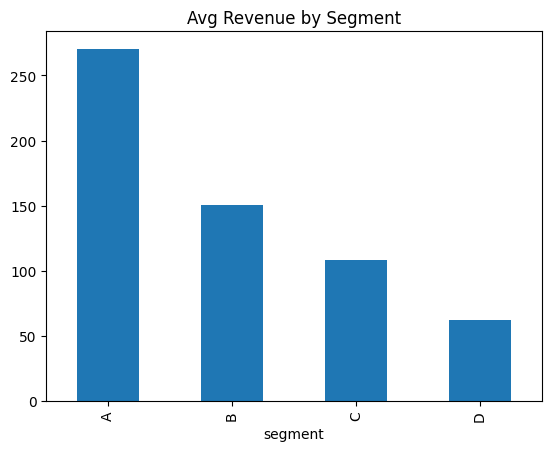

In [243]:
cltv_final_2.groupby("segment")["monetary_value"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Avg Revenue by Segment")
plt.show()

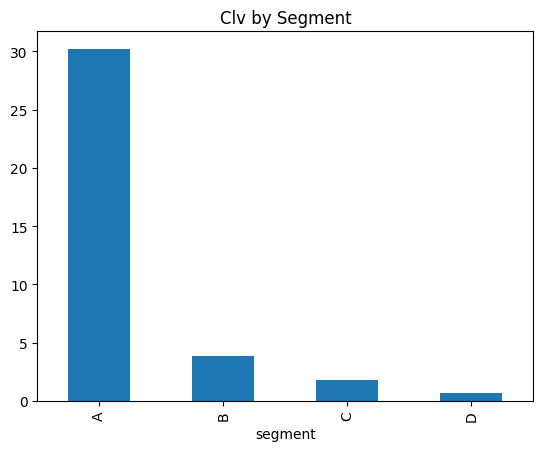

In [245]:
cltv_final_2.groupby("segment")["clv"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Clv by Segment")
plt.show()

## Database Upload & Integration

In [248]:
rfm_new.head()

,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,log_monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising,4.96215
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising,3.33897
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating,4.46843
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating,3.79818
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating,5.28771


In [250]:
clv_c2.head()

,customer_unique_id,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90000,141.90000,0.00001,14.19000,0.00152,0.02224,B
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19000,27.19000,0.00001,2.71900,0.00029,0.00082,D
2,0000f46a3911fa3c0805444483337064,1,1,86.22000,86.22000,0.00001,8.62200,0.00092,0.00821,C
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62000,43.62000,0.00001,4.36200,0.00047,0.00210,D
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89000,196.89000,0.00001,19.68900,0.00211,0.04281,A


In [252]:
cltv_final_2.head()

,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv,segment
0,004288347e5e88a27ded2bb23747066c,1.00000,24.42857,56.85714,103.28000,0.00124,0.00495,0.01470,122.38124,1.91370,C
1,00a39521eb40f7012db50455bf083460,1.00000,1.57143,14.00000,26.78000,0.00325,0.01285,0.03766,34.92452,1.39705,C
2,011575986092c30523ecb71ff10cb473,1.00000,8.57143,27.57143,80.32000,0.00213,0.00844,0.02492,96.13279,2.54620,C
3,011b4adcd54683b480c4d841250a987f,1.00000,25.28571,53.14286,149.88000,0.00142,0.00565,0.01678,175.65553,3.13453,B
4,012452d40dafae4df401bced74cdb490,1.00000,47.14286,62.42857,42.50000,0.00169,0.00675,0.02005,52.89602,1.12822,D


In [254]:
nbd_summary.head()

,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


In [256]:
nbd_summary.reset_index(inplace=True)

In [258]:
nbd_summary.head()

,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
2,0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
3,0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
4,0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


In [260]:
nbd_summary.to_csv("nbd_summary.csv", index=False)

In [168]:
q_create_table_rfm = """
CREATE TABLE IF NOT EXISTS rfm_customer_segments (
    
    customer_unique_id VARCHAR(50) PRIMARY KEY,
    
    recency_days INT,
    frequency INT,
    monetary DECIMAL(10,2),
    
    last_purchase DATETIME,
    
    aov DECIMAL(10,2),
    
    recency_score TINYINT,
    frequency_score TINYINT,
    monetary_score TINYINT,
    
    RFM_SCORE VARCHAR(5),
    
    segment VARCHAR(30),
    
    log_monetary FLOAT

);
"""

cursor.execute(q_create_table_rfm)
conn.commit()

In [170]:
q_load_data_rfm ="""
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/rfm.csv'
INTO TABLE rfm_customer_segments
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_rfm)
conn.commit()

In [172]:
pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_28504\2425857725.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 10;", conn)


,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,log_monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising,4.96214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising,3.33897
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating,4.46843
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating,3.79818
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating,5.28771
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98000,2018-04-05 19:33:16,166.98000,4,1,4,41,promising,5.12385
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38000,2018-04-20 12:57:23,35.38000,4,1,1,41,promising,3.59402
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18000,2018-02-28 11:15:41,419.18000,3,1,5,31,about_to_sleep,6.04068
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12000,2017-03-04 23:32:12,150.12000,1,1,4,11,hibernating,5.01807
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76000,2018-03-12 15:22:12,129.76000,4,1,3,41,promising,4.87336


In [174]:
q_rfm_update = """
UPDATE rfm_customer_segments
SET log_monetary = LN(1 + monetary)
WHERE monetary IS NOT NULL AND monetary >= 0;
"""

cursor.execute(q_rfm_update)
conn.commit()

In [176]:
pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_28504\1514213952.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 5;", conn)


,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,log_monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising,4.96214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising,3.33897
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating,4.46843
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating,3.79818
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating,5.28771


In [178]:
q_rfm_update2 = """
UPDATE rfm_customer_segments
SET segment = TRIM(REPLACE(segment, '\r', ''));;
"""

cursor.execute(q_rfm_update2)
conn.commit()

In [180]:
pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_28504\1514213952.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM rfm_customer_segments LIMIT 5;", conn)


,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,log_monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising,4.96214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising,3.33897
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating,4.46843
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating,3.79818
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating,5.28771


In [182]:
q_create_table_clv_c = """
CREATE TABLE IF NOT EXISTS clv_customer_segments (

    customer_unique_id VARCHAR(50) PRIMARY KEY,

    total_transaction INT,
    total_unit INT,

    total_price DECIMAL(12,2),
    average_order_value DECIMAL(12,2),

    purchase_frequency DOUBLE,

    profit_margin DECIMAL(12,2),

    customer_value DOUBLE,
    cltv DOUBLE,

    segment CHAR(1)

);
"""

cursor.execute(q_create_table_clv_c)
conn.commit()

In [184]:
q_load_data_clv_c ="""
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/cltc_c.csv'
INTO TABLE clv_customer_segments
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_clv_c)
conn.commit()

In [186]:
pd.read_sql("SELECT * FROM clv_customer_segments LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_28504\275786029.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM clv_customer_segments LIMIT 5;", conn)


,customer_unique_id,total_transaction,total_unit,total_price,average_order_value,purchase_frequency,profit_margin,customer_value,cltv,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90000,141.90000,0.00001,14.19000,0.00152,0.02224,B
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19000,27.19000,0.00001,2.72000,0.00029,0.00082,D
2,0000f46a3911fa3c0805444483337064,1,1,86.22000,86.22000,0.00001,8.62000,0.00092,0.00821,C
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62000,43.62000,0.00001,4.36000,0.00047,0.00210,D
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89000,196.89000,0.00001,19.69000,0.00211,0.04281,A


In [188]:
q_create_table_cltv = """
CREATE TABLE IF NOT EXISTS clv_bgnbd_results (

    customer_unique_id VARCHAR(50) PRIMARY KEY,

    frequency DOUBLE,
    recency DOUBLE,
    T DOUBLE,

    monetary_value DECIMAL(12,2),

    expected_purc_1_week DOUBLE,
    expected_purc_1_month DOUBLE,
    expected_purc_3_month DOUBLE,

    expected_average_profit DECIMAL(12,2),

    clv DOUBLE,

    segment CHAR(1)

);
"""

cursor.execute(q_create_table_cltv)
conn.commit()

In [190]:
q_load_data_cltv ="""
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/cltv_p.csv'
INTO TABLE clv_bgnbd_results
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_cltv)
conn.commit()

In [192]:
pd.read_sql("SELECT * FROM clv_bgnbd_results LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_28504\1998652676.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM clv_bgnbd_results LIMIT 5;", conn)


,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv,segment
0,004288347e5e88a27ded2bb23747066c,1.00000,24.42857,56.85714,103.28000,0.00124,0.00495,0.01470,122.38000,1.91370,C
1,00a39521eb40f7012db50455bf083460,1.00000,1.57143,14.00000,26.78000,0.00325,0.01285,0.03766,34.92000,1.39705,C
2,011575986092c30523ecb71ff10cb473,1.00000,8.57143,27.57143,80.32000,0.00213,0.00844,0.02492,96.13000,2.54620,C
3,011b4adcd54683b480c4d841250a987f,1.00000,25.28571,53.14286,149.88000,0.00142,0.00565,0.01678,175.66000,3.13453,B
4,012452d40dafae4df401bced74cdb490,1.00000,47.14286,62.42857,42.50000,0.00169,0.00675,0.02005,52.90000,1.12822,D


In [262]:
q_create_table_cltv2 = """
CREATE TABLE IF NOT EXISTS nbd_summary (

    customer_unique_id VARCHAR(50) PRIMARY KEY,

    frequency DOUBLE,
    recency DOUBLE,
    T DOUBLE,

    monetary_value DECIMAL(12,2),

    expected_purc_1_week DOUBLE,
    expected_purc_1_month DOUBLE,
    expected_purc_3_month DOUBLE

);
"""

cursor.execute(q_create_table_cltv2)
conn.commit()

In [264]:
q_load_data_cltv2 ="""
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/nbd_summary.csv'
INTO TABLE nbd_summary
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_cltv2)
conn.commit()

In [266]:
pd.read_sql("SELECT * FROM nbd_summary LIMIT 5;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_23760\2990391003.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM nbd_summary LIMIT 5;", conn)


,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
2,0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
3,0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
4,0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


In [268]:
conn.close()

In [270]:
import joblib

In [272]:
joblib.dump(bgf, "bgf_model.pkl")

['bgf_model.pkl']

In [274]:
joblib.dump(ggf, "ggf_model.pkl")

['ggf_model.pkl']

In [276]:
model_params = {
    "bgf_params": bgf.params_,
    "ggf_params": ggf.params_
}

joblib.dump(model_params, "model_params.pkl")

['model_params.pkl']

## Conclusion

This project demonstrates how customer analytics techniques can be used to understand customer behavior and estimate future value.

Key insights from the analysis:

- RFM segmentation reveals distinct behavioral customer groups
- CLV modeling allows estimation of future customer revenue
- A small portion of customers generates a large share of value

These insights can support marketing strategies such as:

- customer retention campaigns
- targeted promotions
- high-value customer prioritization